# Data Preprocessing & EDA

# Part A — Data Preprocessing

## 1. Feature mapping

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("features.csv")
print("rows:", df.shape[0], "cols:", df.shape[1])
df = df.rename(columns={"LSOA GVA Estimates (millions)": "total_GVA_2023"})

rows: 1129 cols: 83


In [2]:
edu_cols = ["Apprenticeship %"] + [c for c in df.columns if "qualification" in c.lower()]
selected_cols = [
    # target
    "total_GVA_2023",
    # policy
    "Urban_rura", "RUC21NM",
    # business size structure
    "LU_pct_micro_2025_msoa", "LU_pct_small_2025_msoa",
    "LU_pct_medium_2025_msoa", "LU_pct_large_2025_msoa",
    "enterprises_per_1k_residents_2025", "total_enterprises_2025_msoa",
    # economic resilience
    "turnover_diversity_1-HHI_2025_msoa", "LU_diversity_1-HHI_2025",
    "share_enterprises_creative_2025_msoa", "share_enterprises_foundational_2025_msoa",
    "share_enterprises_green_aligned_2025_msoa", "share_enterprises_industrial_2025_msoa",
    "share_enterprises_kibs_2025_msoa", "share_enterprises_anchor_2025_msoa",
    "share_enterprises_public_2025_msoa", "share_enterprises_private_2025_msoa",
    # employment
    "employment_rate_per_pop", "full_to_part_ratio", "total_employees",
    # controls: deprivation
    "IMD_decile", "Income_decile", "Employment_decile",
    "Education_decile", "AdultSkills_decile",
    # controls: digital connectivity
    "Percentage of connections receiving less than 10Mbit/s broadband",
    "Average download speed (Mbit/s)",
    "Percentage of homes unable to receive at least 30Mbit/s broadband",
    # controls: transport access
    "bus_stop_density", "dist_to_primary_m",
    # controls: population
    "Mid-2024 population", "Working_Age_Pop", "Pct_Working_Age",
    # ids
    "LSOA21CD", "LSOA21NM", "MSOA21CD", "MSOA21NM", "area_km2",
    # raw counts for feature engineering
    "LU_micro_2025_msoa", "LU_small_2025_msoa", "LU_medium_2025_msoa",
    "LU_large_2025_msoa", "LU_total_2025_msoa",
    "full_time_employees", "part_time_employees",
] + edu_cols

df = df[selected_cols]
print(df.shape)

(1129, 54)


## 2. Inspect data overview

In [3]:
# missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}))

                    missing_count  missing_pct
total_GVA_2023                105          9.3
full_to_part_ratio              4          0.4


In [4]:
print(df.dtypes.value_counts()) # data types
print("Duplicate LSOA codes:", df["LSOA21CD"].duplicated().sum())

float64    32
int64      16
object      6
Name: count, dtype: int64
Duplicate LSOA codes: 4


In [5]:
df.describe()

,total_GVA_2023,LU_pct_micro_2025_msoa,LU_pct_small_2025_msoa,LU_pct_medium_2025_msoa,LU_pct_large_2025_msoa,enterprises_per_1k_residents_2025,total_enterprises_2025_msoa,turnover_diversity_1-HHI_2025_msoa,LU_diversity_1-HHI_2025,share_enterprises_creative_2025_msoa,...,LU_total_2025_msoa,full_time_employees,part_time_employees,Apprenticeship %,"Level 1 and entry level qualifications: 1 to 4 GCSEs grade A* to C, Any GCSEs at other grades, O levels or CSEs (any grades), 1 AS level, NVQ level 1, Foundation GNVQ, Basic or Essential Skills %","Level 2 qualifications: 5 or more GCSEs (A* to C or 9 to 4), O levels (passes), CSEs (grade 1), School Certification, 1 A level, 2 to 3 AS levels, VCEs, Intermediate or Higher Diploma, Welsh Baccalaureate Intermediate Diploma, NVQ level 2, Intermediate GNVQ, City and Guilds Craft, BTEC First or General Diploma, RSA Diploma %","Level 3 qualifications: 2 or more A levels or VCEs, 4 or more AS levels, Higher School Certificate, Progression or Advanced Diploma, Welsh Baccalaureate Advance Diploma, NVQ level 3; Advanced GNVQ, City and Guilds Advanced Craft, ONC, OND, BTEC National, RSA Advanced Diploma %","Level 4 qualifications or above: degree (BA, BSc), higher degree (MA, PhD, PGCE), NVQ level 4 to 5, HNC, HND, RSA Higher Diploma, BTEC Higher level, professional qualifications (for example, teaching, nursing, accountancy) %",No qualifications %,"Other: vocational or work-related qualifications, other qualifications achieved in England or Wales, qualifications achieved outside England or Wales (equivalent not stated or unknown) %"
count,1024.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,...,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000
mean,84.864619,0.857709,0.112123,0.026563,0.003605,223.693985,385.323295,0.789844,0.894069,0.137352,...,449.357839,270.699734,676.802480,3.724171,7.473532,10.126812,12.536070,30.533225,11.258126,2.107756
std,264.108469,0.064586,0.048992,0.018015,0.006103,128.065973,213.078493,0.035241,0.018649,0.056854,...,264.447872,608.709175,1691.152891,1.301719,2.486147,2.507103,4.299041,9.738828,4.549009,0.865209
min,4.977000,0.645985,0.015385,0.000000,0.000000,21.624219,45.000000,0.695886,0.835208,0.000000,...,75.000000,0.000000,0.000000,0.100533,0.231225,0.854529,4.926316,8.686327,0.834422,0.418760
25%,13.362250,0.822785,0.075472,0.013699,0.000000,131.223466,220.000000,0.764414,0.881986,0.100000,...,265.000000,50.000000,100.000000,2.901084,5.851064,8.693714,10.575296,23.222004,7.827396,1.542416
50%,24.274000,0.868263,0.107784,0.023810,0.000000,198.019802,345.000000,0.790898,0.898220,0.130233,...,405.000000,125.000000,225.000000,3.683036,7.290323,10.254433,11.981100,29.522184,10.619894,1.983584
75%,57.575000,0.905660,0.142292,0.036585,0.007407,281.531532,485.000000,0.816569,0.907137,0.166667,...,550.000000,250.000000,500.000000,4.469987,8.988764,11.702750,13.836066,36.630891,14.141732,2.567394
max,4407.307000,0.969697,0.277372,0.097222,0.035714,1100.519931,1270.000000,0.877527,0.929012,0.362205,...,1725.000000,13000.000000,28000.000000,9.344386,17.802727,22.110553,60.199055,74.300699,25.148280,10.844178


C:\Users\qinsh\AppData\Local\Temp\ipykernel_15804\2700626935.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


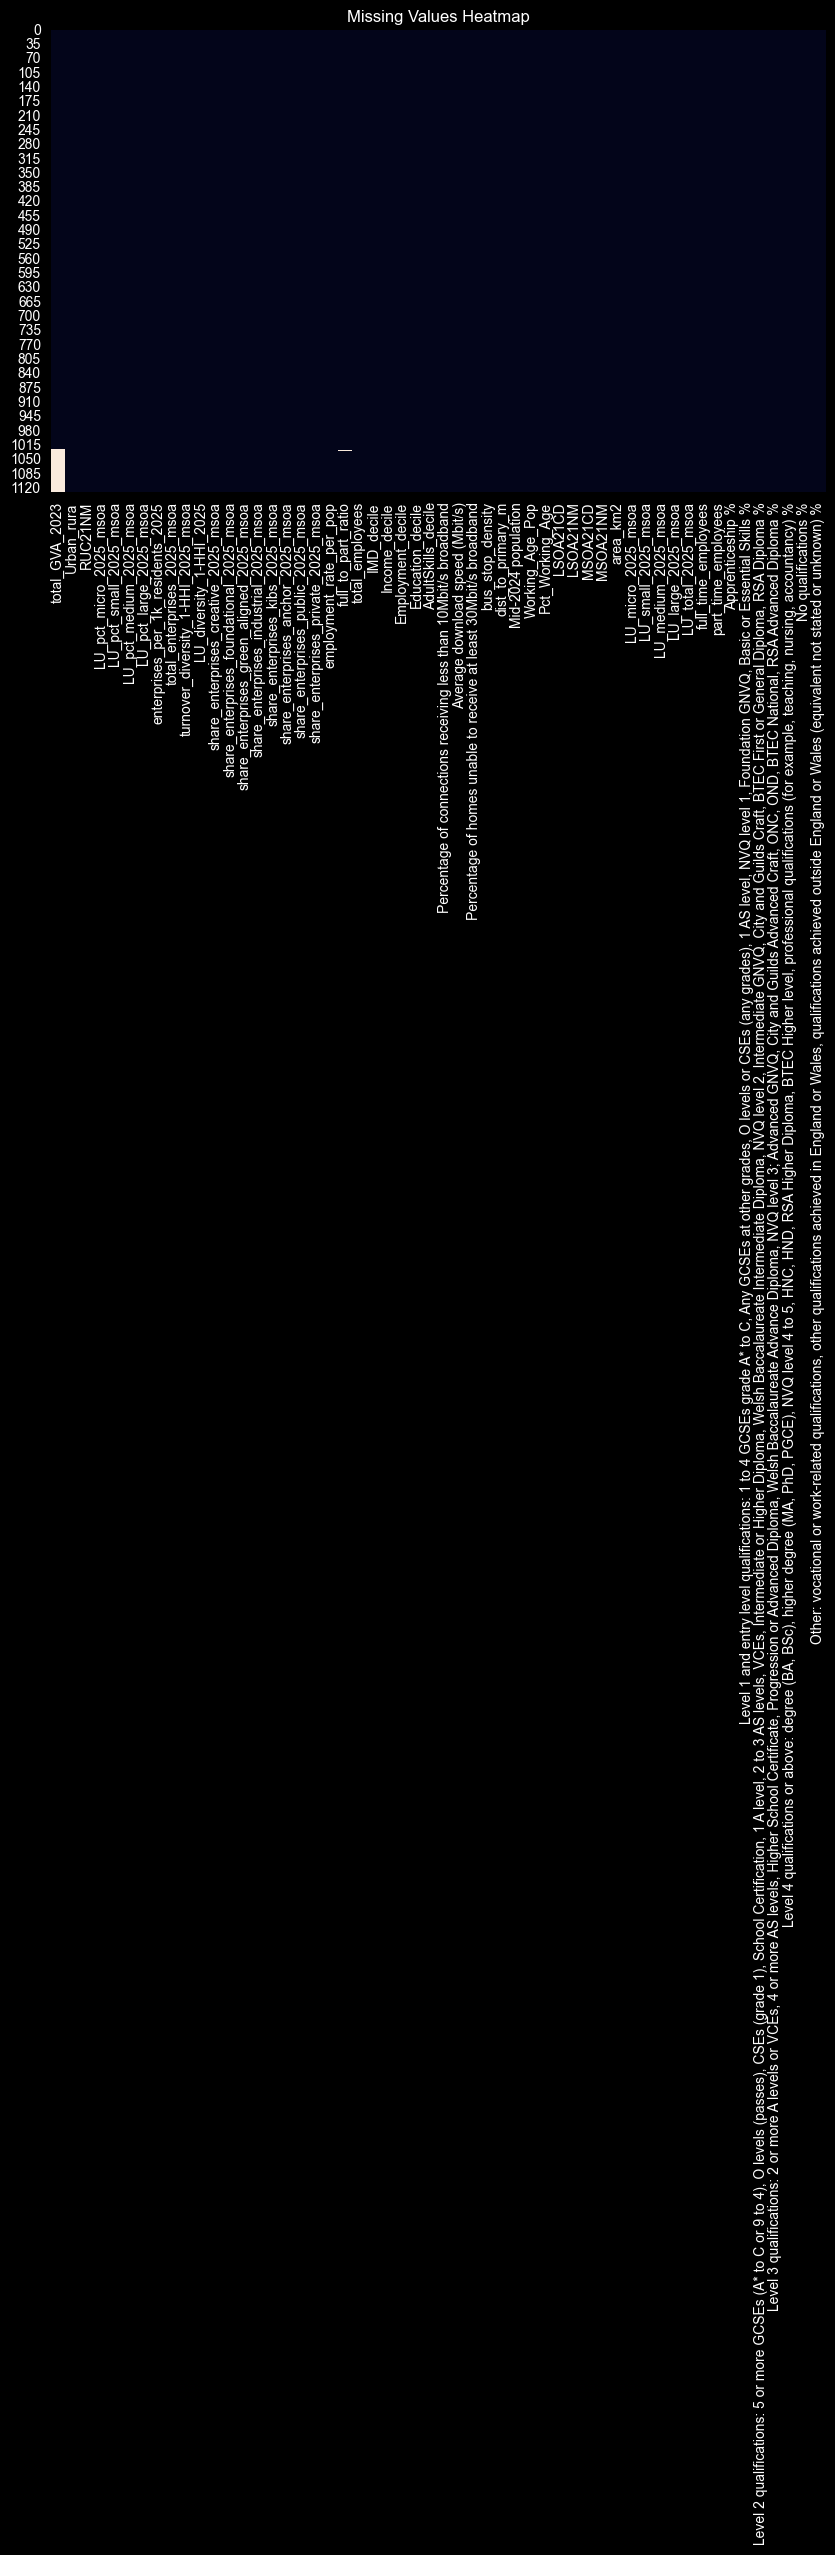

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

## 3. Handle duplicates and missing values

In [7]:
df = df.drop_duplicates(subset="LSOA21CD").copy()
print("after dedup:", df.shape)
print("missing total_GVA_2023:", df["total_GVA_2023"].isna().sum())

after dedup: (1125, 54)
missing total_GVA_2023: 101


In [8]:
# GVA imputation, MSOA-group median, then global median fallback
df["gva_was_imputed"] = df["total_GVA_2023"].isna().astype(int)
n_before = int(df["gva_was_imputed"].sum())

df["total_GVA_2023"] = df.groupby("MSOA21CD")["total_GVA_2023"].transform(
    lambda x: x.fillna(x.median())
)
global_median = df["total_GVA_2023"].median()
df["total_GVA_2023"] = df["total_GVA_2023"].fillna(global_median)

# remaining numeric gap
df["full_to_part_ratio"] = df["full_to_part_ratio"].fillna(df["full_to_part_ratio"].median())
print("Missing GVA before:", n_before)
print("Missing GVA after :", df["total_GVA_2023"].isna().sum())

Missing GVA before: 101
Missing GVA after : 0


In [9]:
# which LSOAs were imputed?
imputed = df[df["gva_was_imputed"] == 1][
    ["LSOA21CD", "LSOA21NM", "MSOA21CD", "total_GVA_2023",
     "employment_rate_per_pop", "IMD_decile"]
].reset_index(drop=True)
print("Total LSOAs imputed:", len(imputed))
imputed

Total LSOAs imputed: 101


,LSOA21CD,LSOA21NM,MSOA21CD,total_GVA_2023,employment_rate_per_pop,IMD_decile
0,E01033838,Reading 020C,E02006940,315.1825,0.374925,7
1,E01033839,Reading 020D,E02006940,315.1825,0.704593,6
2,E01033840,Swindon 008E,E02003219,316.0090,0.000000,8
3,E01033841,Swindon 008F,E02003219,316.0090,0.421348,7
4,E01033842,Swindon 008G,E02003219,316.0090,0.000000,8
...,...,...,...,...,...,...
96,E01035758,Vale of White Horse 014H,E02005991,14.7930,0.267270,9
97,E01035759,Vale of White Horse 015G,E02005992,47.3220,4.711055,9
98,E01035760,Vale of White Horse 015H,E02005992,47.3220,0.561029,9
99,E01035761,Vale of White Horse 015I,E02005992,47.3220,0.069054,9


In [10]:
# per-worker productivity is undefined when there are no workers, then drop those rows
n0 = int((df["total_employees"] == 0).sum())
df = df[df["total_employees"] > 0].copy()
print("Dropped", n0, "rows with total_employees == 0")
print("shape:", df.shape, ", remaining missing values:", int(df.isna().sum().sum()))

Dropped 4 rows with total_employees == 0
shape: (1121, 55) , remaining missing values: 0


## 4. Handle outliers

In [11]:
print("Negative GVA:", int((df["total_GVA_2023"] < 0).sum()))
numeric_cols = df.select_dtypes(include="number").columns
print("IQR outlier counts:")
for c in numeric_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((df[c] < low) | (df[c] > high)).sum())
    if n > 0:
        print(f"{c[:45]:47s} {n}")

Negative GVA: 0
IQR outlier counts:
total_GVA_2023                                  152
LU_pct_micro_2025_msoa                          14
LU_pct_small_2025_msoa                          4
LU_pct_medium_2025_msoa                         26
LU_pct_large_2025_msoa                          37
enterprises_per_1k_residents_2025               47
total_enterprises_2025_msoa                     30
LU_diversity_1-HHI_2025                         9
share_enterprises_creative_2025_msoa            52
share_enterprises_green_aligned_2025_msoa       38
share_enterprises_industrial_2025_msoa          41
share_enterprises_kibs_2025_msoa                13
share_enterprises_anchor_2025_msoa              27
share_enterprises_public_2025_msoa              57
share_enterprises_private_2025_msoa             57
employment_rate_per_pop                         136
full_to_part_ratio                              39
total_employees                                 136
IMD_decile                                   

In [12]:
print(df["employment_rate_per_pop"].describe())
print("Values > 2.0:", int((df["employment_rate_per_pop"] > 2).sum()))
print("Values > 1.0:", int((df["employment_rate_per_pop"] > 1).sum()))
df[df["employment_rate_per_pop"] > 2][
    ["LSOA21NM", "employment_rate_per_pop", "total_employees", "Mid-2024 population", "RUC21NM"]
].sort_values("employment_rate_per_pop", ascending=False)

count    1121.000000
mean        0.499967
std         0.977480
min         0.008043
25%         0.093284
50%         0.197517
75%         0.433705
max        10.999676
Name: employment_rate_per_pop, dtype: float64
Values > 2.0: 54
Values > 1.0: 130


,LSOA21NM,employment_rate_per_pop,total_employees,Mid-2024 population,RUC21NM
1017,Reading 019B,10.999676,34000,3091,Urban: Nearer to a major town or city
176,West Berkshire 011A,8.080475,12250,1516,Smaller rural: Nearer to a major town or city
518,Wokingham 006A,7.944228,12250,1542,Urban: Nearer to a major town or city
263,West Berkshire 009C,7.851759,12500,1592,Larger rural: Nearer to a major town or city
709,Oxford 006D,7.172744,12000,1673,Urban: Nearer to a major town or city
459,Windsor and Maidenhead 012D,7.159091,12600,1760,Urban: Nearer to a major town or city
396,Slough 002D,7.010656,12500,1783,Urban: Nearer to a major town or city
1045,Reading 017H,6.748208,16000,2371,Urban: Nearer to a major town or city
471,Windsor and Maidenhead 011A,6.711409,12000,1788,Larger rural: Nearer to a major town or city
596,Wokingham 009C,5.549950,11000,1982,Urban: Nearer to a major town or city


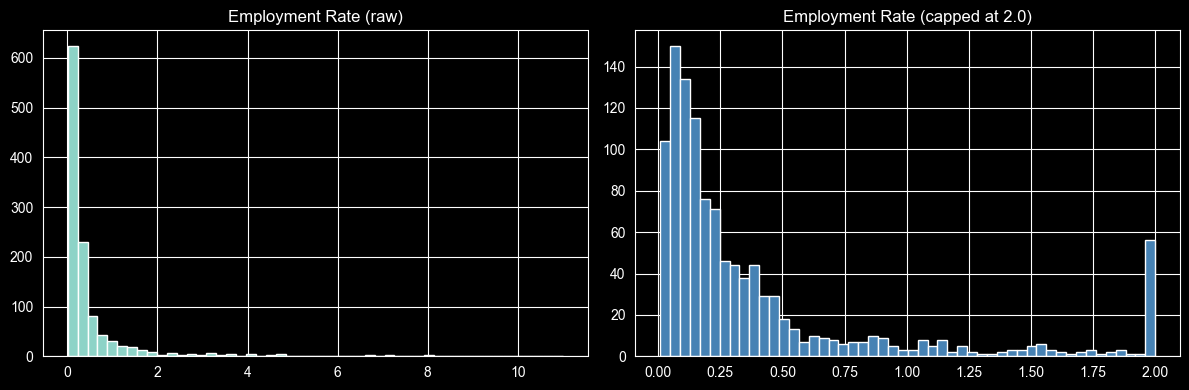

In [13]:
# Values >1 are real (more jobs than residents = commercial/commuter area)
# Values >2 need a decision — cap or investigate further
# For now: cap at 2.0, note this in your methods
df["emp_rate"] = df["employment_rate_per_pop"].clip(upper=2.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["employment_rate_per_pop"].hist(bins=50, ax=axes[0])
axes[0].set_title("Employment Rate (raw)")
df["emp_rate"].hist(bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Employment Rate (capped at 2.0)")
plt.tight_layout()
plt.show()

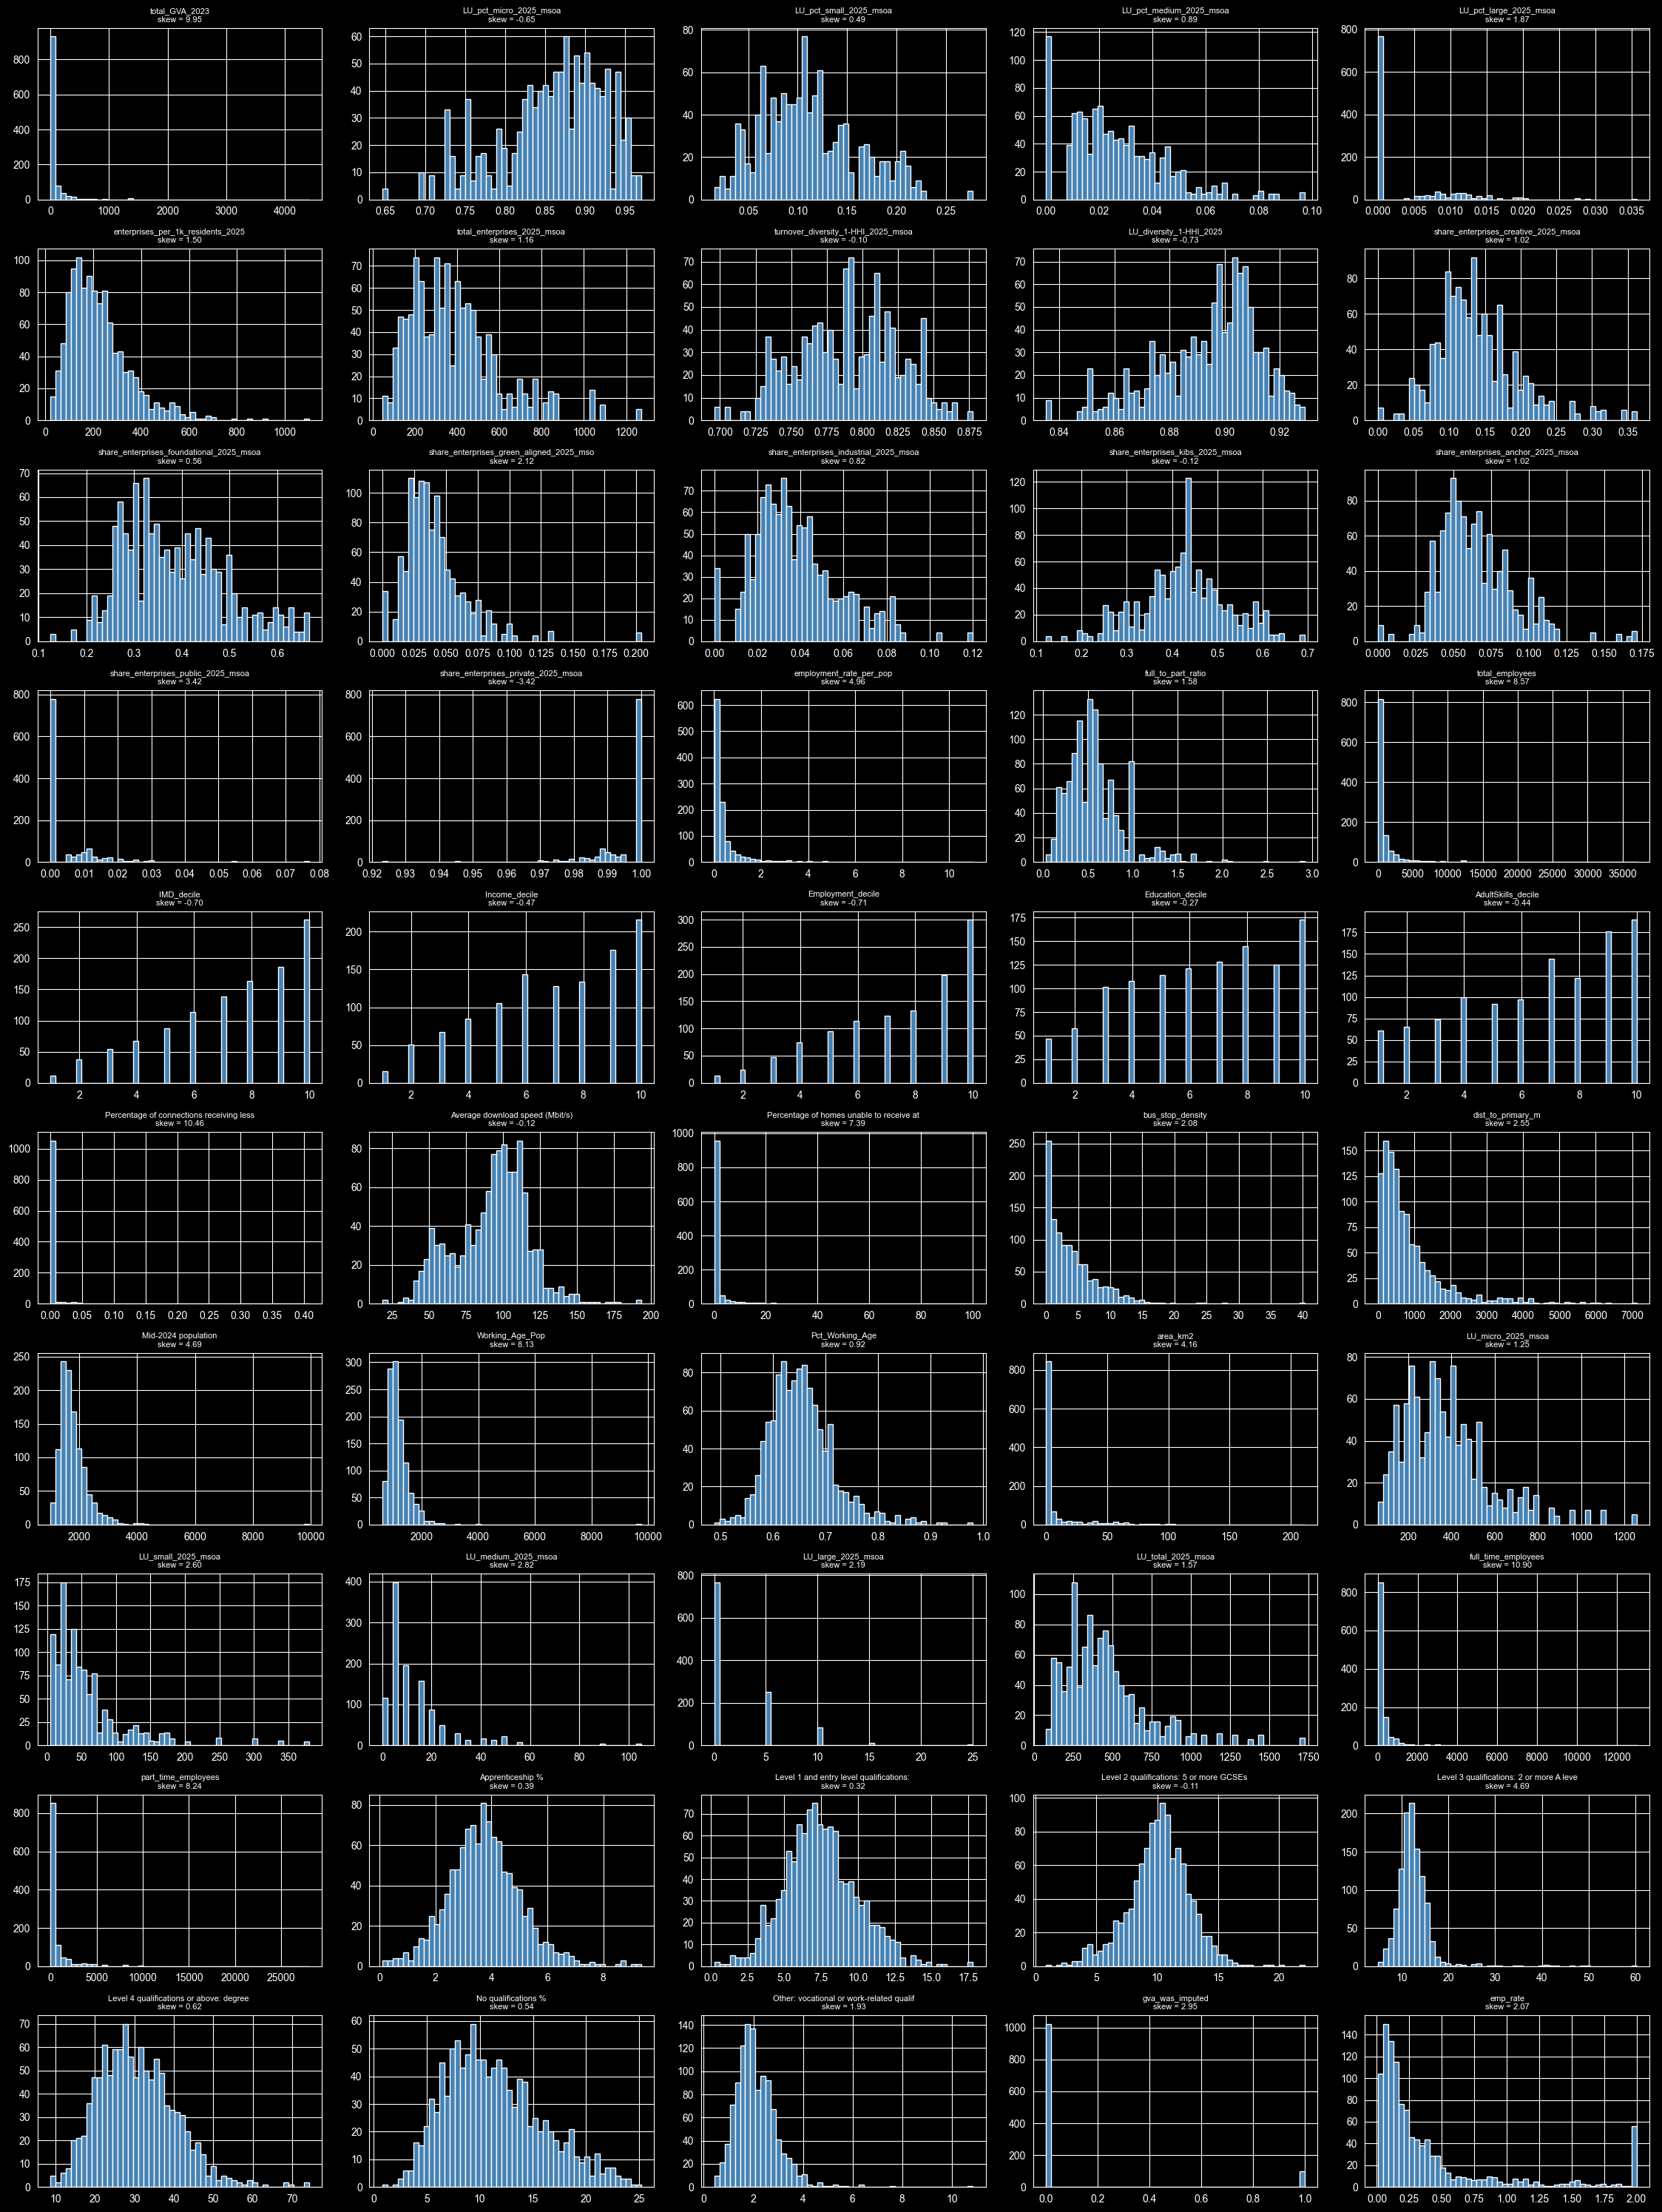

In [14]:
# distribution of every numeric column with skew
numeric_cols = df.select_dtypes(include="number").columns
n = len(numeric_cols); ncol = 5; nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4.5, nrow * 3))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{col[:40]}\nskew = {df[col].skew():.2f}", fontsize=8)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Log transformation

In [15]:
skew = df.select_dtypes(include="number").skew()
print(skew[skew > 1].sort_values(ascending=False))

full_time_employees                                                                                                                                                                                                                                                                      10.900458
Percentage of connections receiving less than 10Mbit/s broadband                                                                                                                                                                                                                         10.463500
total_GVA_2023                                                                                                                                                                                                                                                                            9.954129
total_employees                                                                                                                

In [16]:
log_cols = [
    "full_time_employees", "total_employees", "part_time_employees",
    "Working_Age_Pop", "Mid-2024 population", "area_km2",
    "dist_to_primary_m", "bus_stop_density",
    "enterprises_per_1k_residents_2025", "total_enterprises_2025_msoa",
    "LU_micro_2025_msoa", "LU_small_2025_msoa", "LU_medium_2025_msoa",
    "LU_large_2025_msoa", "LU_total_2025_msoa",
    "total_GVA_2023",
]
for col in log_cols:
    df[f"log_{col}"] = np.log1p(df[col])

for c in log_cols:
    print(f"{c[:35]:37s} {df[c].skew():7.2f} -> {df['log_' + c].skew():7.2f}")

full_time_employees                     10.90 ->    0.08
total_employees                          8.57 ->    0.38
part_time_employees                      8.24 ->    0.51
Working_Age_Pop                          8.13 ->    1.01
Mid-2024 population                      4.69 ->    0.97
area_km2                                 4.16 ->    1.49
dist_to_primary_m                        2.55 ->   -0.85
bus_stop_density                         2.08 ->    0.03
enterprises_per_1k_residents_2025        1.50 ->   -0.36
total_enterprises_2025_msoa              1.16 ->   -0.39
LU_micro_2025_msoa                       1.25 ->   -0.28
LU_small_2025_msoa                       2.60 ->   -0.11
LU_medium_2025_msoa                      2.82 ->   -0.61
LU_large_2025_msoa                       2.19 ->    0.94
LU_total_2025_msoa                       1.57 ->   -0.17
total_GVA_2023                           9.95 ->    1.12


## 6. Feature engineering

In [17]:
df["gva_per_worker_2023"] = df["total_GVA_2023"] * 1e6 / df["total_employees"]
df["log_gva_per_worker_2023"] = np.log1p(df["gva_per_worker_2023"])
df["full_time_share"] = df["full_time_employees"] / (
    df["full_time_employees"] + df["part_time_employees"]
)
print(df[["total_GVA_2023", "gva_per_worker_2023", "full_time_share"]].describe())

       total_GVA_2023  gva_per_worker_2023  full_time_share
count     1121.000000         1.121000e+03      1121.000000
mean        86.270989         1.294091e+05         0.345045
std        259.458509         2.923455e+05         0.115236
min          4.977000         5.607500e+02         0.032258
25%         14.024000         5.981529e+04         0.272727
50%         24.964000         7.936222e+04         0.333333
75%         59.131000         1.173511e+05         0.428571
max       4407.307000         6.185720e+06         0.744681


## 7. Train / test split

In [18]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["MSOA21CD"]))
train = df.iloc[train_idx].copy()
test = df.iloc[test_idx].copy()
print("Train:", train.shape, "Test:", test.shape)

Train: (900, 75) Test: (221, 75)


## 8. One-hot encoding

In [19]:
from sklearn.preprocessing import OneHotEncoder
cat_cols = ["Urban_rura", "RUC21NM"]

encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoder.fit(train[cat_cols])

def encode(frame):
    arr = encoder.transform(frame[cat_cols])
    names = encoder.get_feature_names_out(cat_cols)
    enc = pd.DataFrame(arr, columns=names, index=frame.index)
    return pd.concat([frame.drop(columns=cat_cols), enc], axis=1)

train = encode(train)
test = encode(test)
print([c for c in train.columns if c.startswith(("Urban_rura_", "RUC21NM_"))])

['Urban_rura_Urban', 'RUC21NM_Larger rural: Nearer to a major town or city', 'RUC21NM_Smaller rural: Further from a major town or city', 'RUC21NM_Smaller rural: Nearer to a major town or city', 'RUC21NM_Urban: Further from a major town or city', 'RUC21NM_Urban: Nearer to a major town or city']


# Part B — EDA & DAG validation

In [20]:
short = lambda c: c[:32]
target = "log_gva_per_worker_2023"
target_total = "log_total_GVA_2023"

def winsorize(frame, cols, lo=0.01, hi=0.99):
    out = frame.copy()
    for c in cols:
        out[c] = out[c].clip(out[c].quantile(lo), out[c].quantile(hi))
    return out

for frame in (train, test):
    frame["is_swindon"] = np.where(
        frame["LSOA21NM"].str.replace(r"\s\d.*", "", regex=True).eq("Swindon"),
        "Swindon", "Others")

num_feats = train.select_dtypes("number").columns.tolist()
dfw = winsorize(train, num_feats)

C:\Users\qinsh\AppData\Local\Temp\ipykernel_15804\497798797.py:8: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[c] = out[c].clip(out[c].quantile(lo), out[c].quantile(hi))


## Feature selection (DAG nodes)

In [21]:
dag = {
    "Policy proxy":     ["Urban_rura_Urban"],
    "Business size":    ["LU_pct_micro_2025_msoa", "LU_pct_large_2025_msoa",
                         "log_enterprises_per_1k_residents_2025"],
    "Econ resilience":  ["turnover_diversity_1-HHI_2025_msoa", "LU_diversity_1-HHI_2025",
                         "share_enterprises_kibs_2025_msoa", "share_enterprises_foundational_2025_msoa"],
    "Employment":       ["emp_rate", "full_time_share"],
    "Size control":     ["log_Mid-2024 population"],
    "Deprivation ctrl": ["IMD_decile"],
}
dag_cols = [c for cols in dag.values() for c in cols]
dag_num = dag_cols
ids = ["LSOA21CD", "LSOA21NM", "MSOA21CD", "MSOA21NM"]
targets = ["log_total_GVA_2023", "log_gva_per_worker_2023"]
cols = ids + targets + ["is_swindon"] + dag_cols
print("selected features:", len(dag_cols))

selected features: 12


## B1. Target variables - total GVA vs GVA per worker (2023)

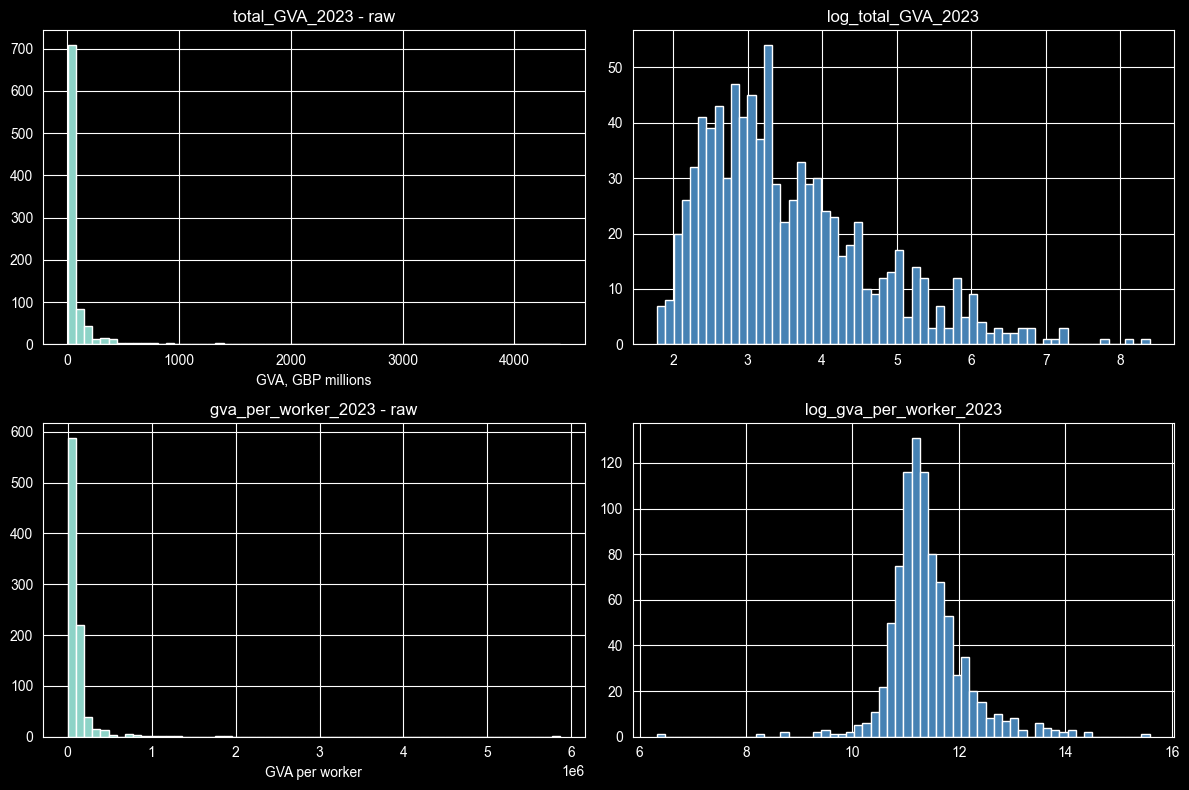

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
train["total_GVA_2023"].hist(bins=60, ax=axes[0, 0], edgecolor="white")
axes[0, 0].set_title("total_GVA_2023 - raw"); axes[0, 0].set_xlabel("GVA, GBP millions")
train["log_total_GVA_2023"].hist(bins=60, ax=axes[0, 1], edgecolor="white", color="steelblue")
axes[0, 1].set_title("log_total_GVA_2023")
train["gva_per_worker_2023"].hist(bins=60, ax=axes[1, 0], edgecolor="white")
axes[1, 0].set_title("gva_per_worker_2023 - raw"); axes[1, 0].set_xlabel("GVA per worker")
train["log_gva_per_worker_2023"].hist(bins=60, ax=axes[1, 1], edgecolor="white", color="steelblue")
axes[1, 1].set_title("log_gva_per_worker_2023")
plt.tight_layout(); plt.show()

In [23]:
cols_show = ["LSOA21NM", "total_GVA_2023", "Urban_rura_Urban"]
print("TOP 5 by total_GVA_2023")
print(train.nlargest(5, "total_GVA_2023")[cols_show])
print()
print("BOTTOM 5 by total_GVA_2023")
print(train.nsmallest(5, "total_GVA_2023")[cols_show])

TOP 5 by total_GVA_2023
          LSOA21NM  total_GVA_2023  Urban_rura_Urban
1017  Reading 019B        4407.307               1.0
28    Swindon 022C        3412.047               1.0
694    Oxford 008A        2349.570               1.0
408    Slough 003G        1406.197               1.0
1107   Oxford 008F        1335.489               1.0

BOTTOM 5 by total_GVA_2023
          LSOA21NM  total_GVA_2023  Urban_rura_Urban
49    Swindon 001F           4.977               0.0
290   Reading 014B           5.115               1.0
16    Swindon 023D           5.126               1.0
40    Swindon 004C           5.253               1.0
669  Cherwell 017E           5.318               1.0


## B2. Bivariate analysis - validate the causal chain step by step

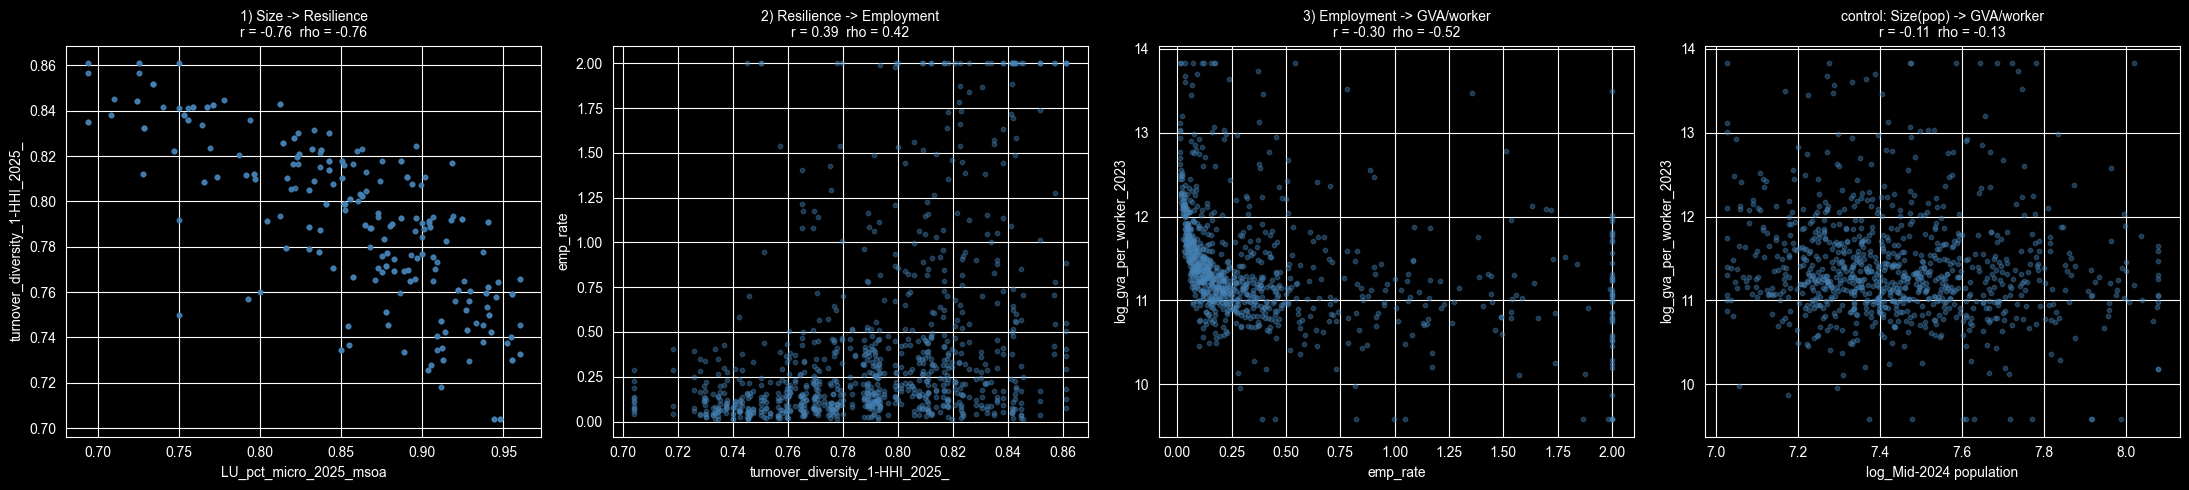

In [24]:
steps = [
    ("LU_pct_micro_2025_msoa", "turnover_diversity_1-HHI_2025_msoa", "1) Size -> Resilience"),
    ("turnover_diversity_1-HHI_2025_msoa", "emp_rate", "2) Resilience -> Employment"),
    ("emp_rate", target, "3) Employment -> GVA/worker"),
    ("log_Mid-2024 population", target, "control: Size(pop) -> GVA/worker"),
]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (x, y, title) in zip(axes, steps):
    ax.scatter(dfw[x], dfw[y], s=10, alpha=0.4, color="steelblue")
    ax.set_xlabel(x[:30]); ax.set_ylabel(y[:30])
    ax.set_title(f"{title}\nr = {dfw[x].corr(dfw[y]):.2f}  "
                 f"rho = {dfw[x].corr(dfw[y], method='spearman'):.2f}", fontsize=10)
plt.tight_layout()
plt.show()

## B3. Business size structure

In [25]:
bss_cols = ["LU_pct_micro_2025_msoa", "LU_pct_small_2025_msoa",
            "LU_pct_medium_2025_msoa", "LU_pct_large_2025_msoa"]
labels = ["Micro", "Small", "Medium", "Large"]
print("Mean business size distribution")
print(train[bss_cols].mean())
print()
print("Sum check")
print(train[bss_cols].sum(axis=1).describe())

Mean business size distribution
LU_pct_micro_2025_msoa     0.857577
LU_pct_small_2025_msoa     0.112292
LU_pct_medium_2025_msoa    0.026379
LU_pct_large_2025_msoa     0.003752
dtype: float64

Sum check
count    9.000000e+02
mean     1.000000e+00
std      2.649770e-10
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


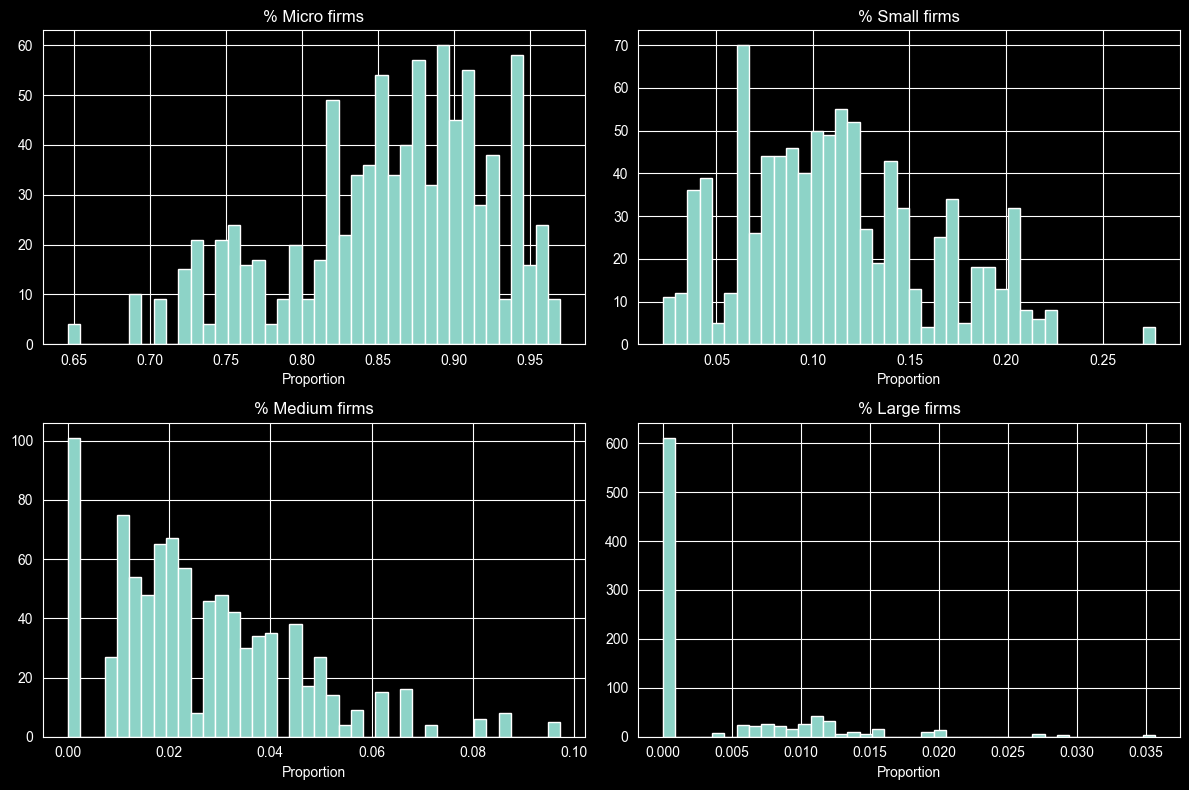

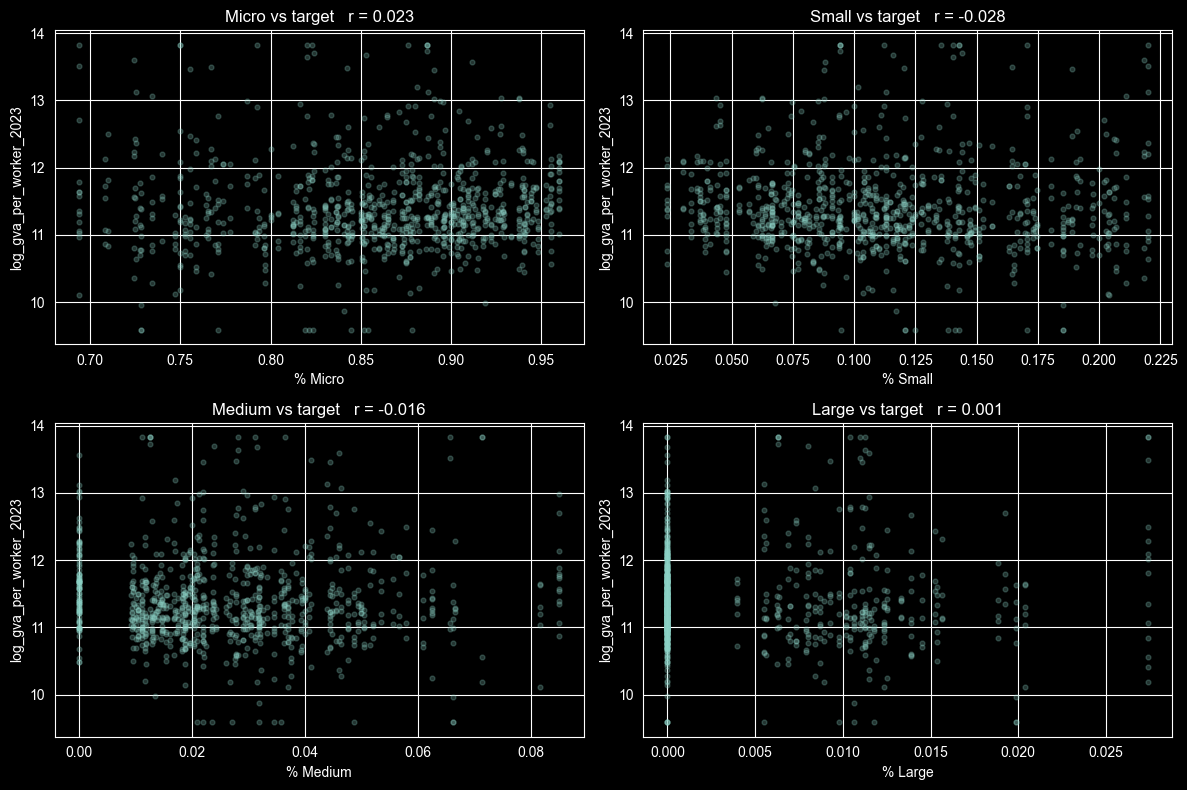

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, label in zip(axes.flatten(), bss_cols, labels):
    train[col].hist(bins=40, ax=ax, edgecolor="white")
    ax.set_title(f"% {label} firms"); ax.set_xlabel("Proportion")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, label in zip(axes.flatten(), bss_cols, labels):
    r = dfw[col].corr(dfw[target])
    ax.scatter(dfw[col], dfw[target], alpha=0.25, s=12)
    ax.set_xlabel(f"% {label}"); ax.set_ylabel(target)
    ax.set_title(f"{label} vs target   r = {r:.3f}")
plt.tight_layout(); plt.show()

## B4. Economic resilience (diversity)

       turnover_diversity_1-HHI_2025_msoa  LU_diversity_1-HHI_2025
count                          900.000000               900.000000
mean                             0.790132                 0.893473
std                              0.035728                 0.019216
min                              0.695886                 0.835208
25%                              0.764800                 0.881294
50%                              0.791583                 0.897959
75%                              0.817036                 0.907067
max                              0.877527                 0.929012


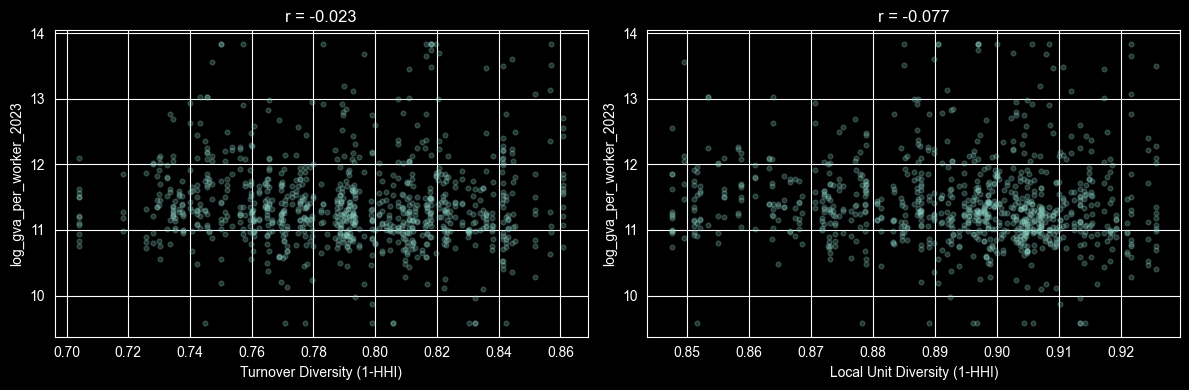

In [27]:
diversity_cols = ["turnover_diversity_1-HHI_2025_msoa", "LU_diversity_1-HHI_2025"]
print(train[diversity_cols].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labs = ["Turnover Diversity (1-HHI)", "Local Unit Diversity (1-HHI)"]
for ax, col, lab in zip(axes, diversity_cols, labs):
    r = dfw[col].corr(dfw[target])
    ax.scatter(dfw[col], dfw[target], alpha=0.25, s=12)
    ax.set_xlabel(lab); ax.set_ylabel(target); ax.set_title(f"r = {r:.3f}")
plt.tight_layout(); plt.show()

## B5. Sector composition

In [28]:
sector_cols = [
    "share_enterprises_kibs_2025_msoa", "share_enterprises_foundational_2025_msoa",
    "share_enterprises_creative_2025_msoa", "share_enterprises_industrial_2025_msoa",
    "share_enterprises_green_aligned_2025_msoa", "share_enterprises_anchor_2025_msoa",
]
print("Sector share means")
print(train[sector_cols].mean().sort_values(ascending=False))
print()
print("Correlation with target")
print(dfw[sector_cols + [target]].corr()[target].drop(target).sort_values(ascending=False))

Sector share means
share_enterprises_kibs_2025_msoa             0.427719
share_enterprises_foundational_2025_msoa     0.379356
share_enterprises_creative_2025_msoa         0.136775
share_enterprises_anchor_2025_msoa           0.064586
share_enterprises_green_aligned_2025_msoa    0.041230
share_enterprises_industrial_2025_msoa       0.037669
dtype: float64

Correlation with target
share_enterprises_foundational_2025_msoa     0.061139
share_enterprises_green_aligned_2025_msoa    0.060376
share_enterprises_industrial_2025_msoa       0.028514
share_enterprises_kibs_2025_msoa            -0.031990
share_enterprises_creative_2025_msoa        -0.043860
share_enterprises_anchor_2025_msoa          -0.088247
Name: log_gva_per_worker_2023, dtype: float64


## B6. Deprivation (policy intervention proxy)

       IMD_decile  Income_decile  Employment_decile  Education_decile  \
count  900.000000     900.000000         900.000000        900.000000   
mean     7.337778       7.001111           7.521111          6.402222   
std      2.397467       2.491587           2.388934          2.696844   
min      1.000000       1.000000           1.000000          1.000000   
25%      6.000000       5.000000           6.000000          4.000000   
50%      8.000000       7.000000           8.000000          7.000000   
75%      9.000000       9.000000          10.000000          9.000000   
max     10.000000      10.000000          10.000000         10.000000   

       AdultSkills_decile  
count          900.000000  
mean             6.611111  
std              2.782411  
min              1.000000  
25%              4.000000  
50%              7.000000  
75%              9.000000  
max             10.000000  
Correlation with target:
IMD_decile            0.023606
Income_decile        -0.018596
Emp

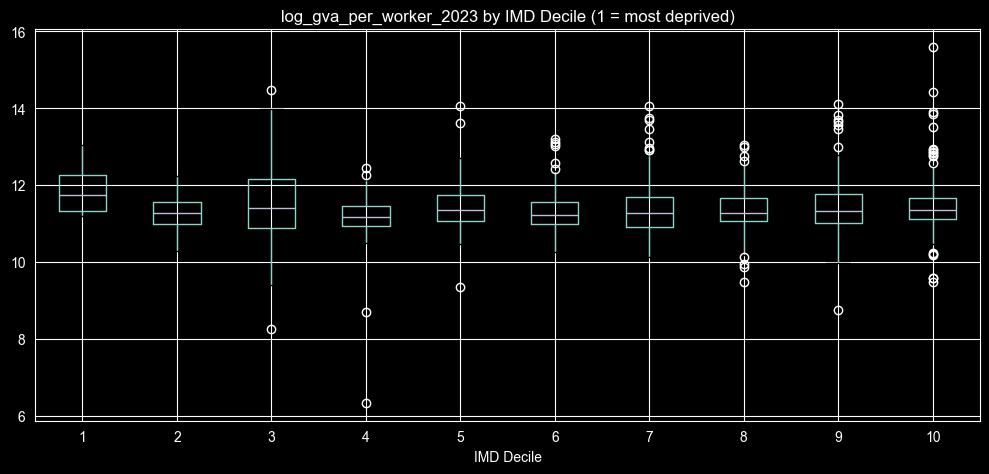

In [29]:
imd_cols = ["IMD_decile", "Income_decile", "Employment_decile",
            "Education_decile", "AdultSkills_decile"]
print(train[imd_cols].describe())
print("Correlation with target:")
print(dfw[imd_cols + [target]].corr()[target].drop(target))

fig, ax = plt.subplots(figsize=(10, 5))
train.boxplot(column=target, by="IMD_decile", ax=ax)
ax.set_title(f"{target} by IMD Decile (1 = most deprived)")
ax.set_xlabel("IMD Decile"); plt.suptitle("")
plt.tight_layout(); plt.show()

## B7. Collinearity - correlation matrix & VIF

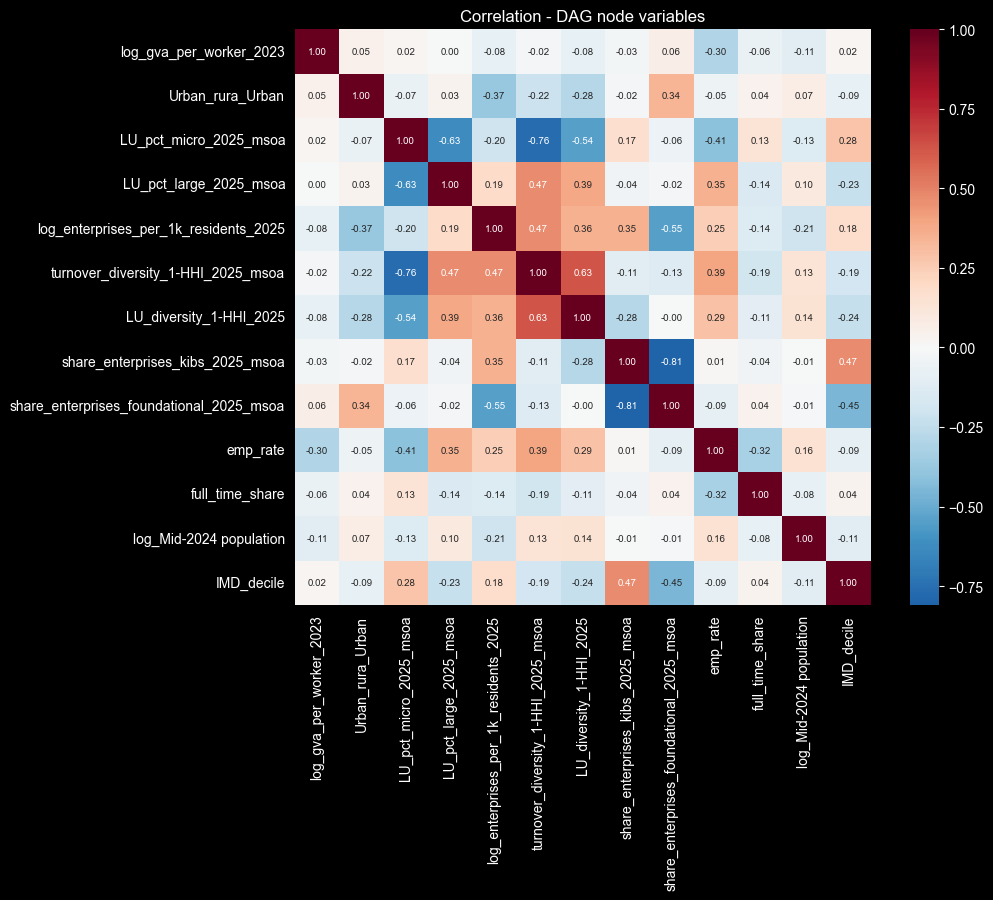

In [30]:
corr = dfw[[target] + dag_num].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, annot_kws={"size": 7})
plt.title("Correlation - DAG node variables"); plt.tight_layout(); plt.show()

In [31]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xv = sm.add_constant(dfw[dag_num].dropna())
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                index=Xv.columns).drop("const").sort_values(ascending=False)
print(vif.round(2))
print("All VIF < 5:", bool((vif < 5).all()))

share_enterprises_foundational_2025_msoa    5.18
share_enterprises_kibs_2025_msoa            4.65
turnover_diversity_1-HHI_2025_msoa          3.92
LU_pct_micro_2025_msoa                      3.85
log_enterprises_per_1k_residents_2025       2.47
LU_diversity_1-HHI_2025                     2.18
LU_pct_large_2025_msoa                      1.73
Urban_rura_Urban                            1.65
IMD_decile                                  1.45
emp_rate                                    1.40
log_Mid-2024 population                     1.26
full_time_share                             1.15
dtype: float64
All VIF < 5: False


## B7b. Pruning after VIF

In [39]:
# foundational was a candidate feature, but its VIF (5.18) exceeds the threshold of 5
# drop it to control multicollinearity, and keep the other features
VIF_THRESHOLD = 5
dropped_by_vif = ["share_enterprises_foundational_2025_msoa"]
dag_cols = [c for c in dag_cols if c not in dropped_by_vif]
dag_num  = [c for c in dag_num  if c not in dropped_by_vif]
cols     = [c for c in cols     if c not in dropped_by_vif]
print("Remaining features:", len(dag_cols))

# re-check VIF on the pruned set
Xv = sm.add_constant(dfw[dag_num].dropna())
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
                index=Xv.columns).drop("const").sort_values(ascending=False)
print(vif.round(2))
print("All VIF <", VIF_THRESHOLD, ":", bool((vif < VIF_THRESHOLD).all()))

Remaining features: 11
turnover_diversity_1-HHI_2025_msoa       3.89
LU_pct_micro_2025_msoa                   3.85
log_enterprises_per_1k_residents_2025    2.37
LU_diversity_1-HHI_2025                  2.15
share_enterprises_kibs_2025_msoa         1.80
LU_pct_large_2025_msoa                   1.73
IMD_decile                               1.40
emp_rate                                 1.40
Urban_rura_Urban                         1.37
log_Mid-2024 population                  1.24
full_time_share                          1.14
dtype: float64
All VIF < 5 : True


## B8. Group comparison - urban/rural & Swindon vs others

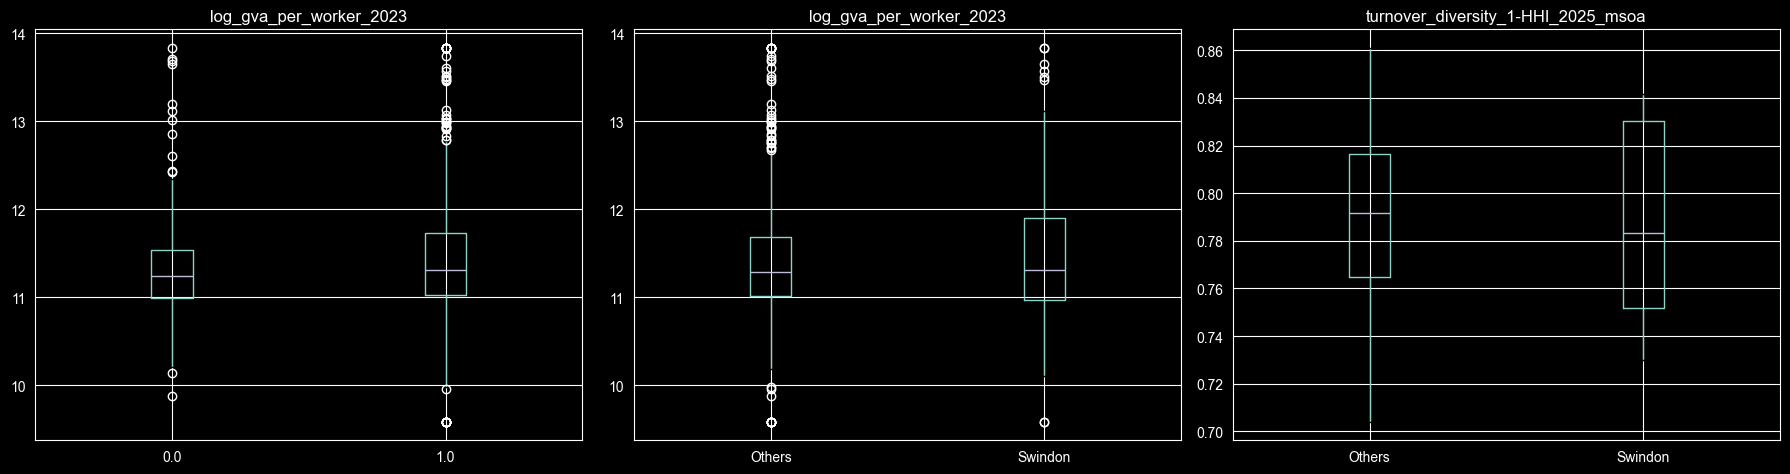

is_swindon                                    Others    Swindon
log_gva_per_worker_2023            mean    11.393023  11.462494
                                   median  11.287041  11.302369
LU_pct_micro_2025_msoa             mean     0.859735   0.843411
                                   median   0.868421   0.857143
turnover_diversity_1-HHI_2025_msoa mean     0.790510   0.787651
                                   median   0.791583   0.783208
emp_rate                           mean     0.401522   0.415401
                                   median   0.207403   0.160624
full_time_share                    mean     0.337376   0.371734
                                   median   0.333333   0.375000


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dfw.boxplot(column=target, by="Urban_rura_Urban", ax=axes[0])
dfw.boxplot(column=target, by="is_swindon", ax=axes[1])
dfw.boxplot(column="turnover_diversity_1-HHI_2025_msoa", by="is_swindon", ax=axes[2])
for ax in axes:
    ax.set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.show()

print(train.groupby("is_swindon")[[
    target, "LU_pct_micro_2025_msoa",
    "turnover_diversity_1-HHI_2025_msoa", "emp_rate", "full_time_share",
]].agg(["mean", "median"]).T)

## B9. Spatial analysis - map & spatial autocorrelation

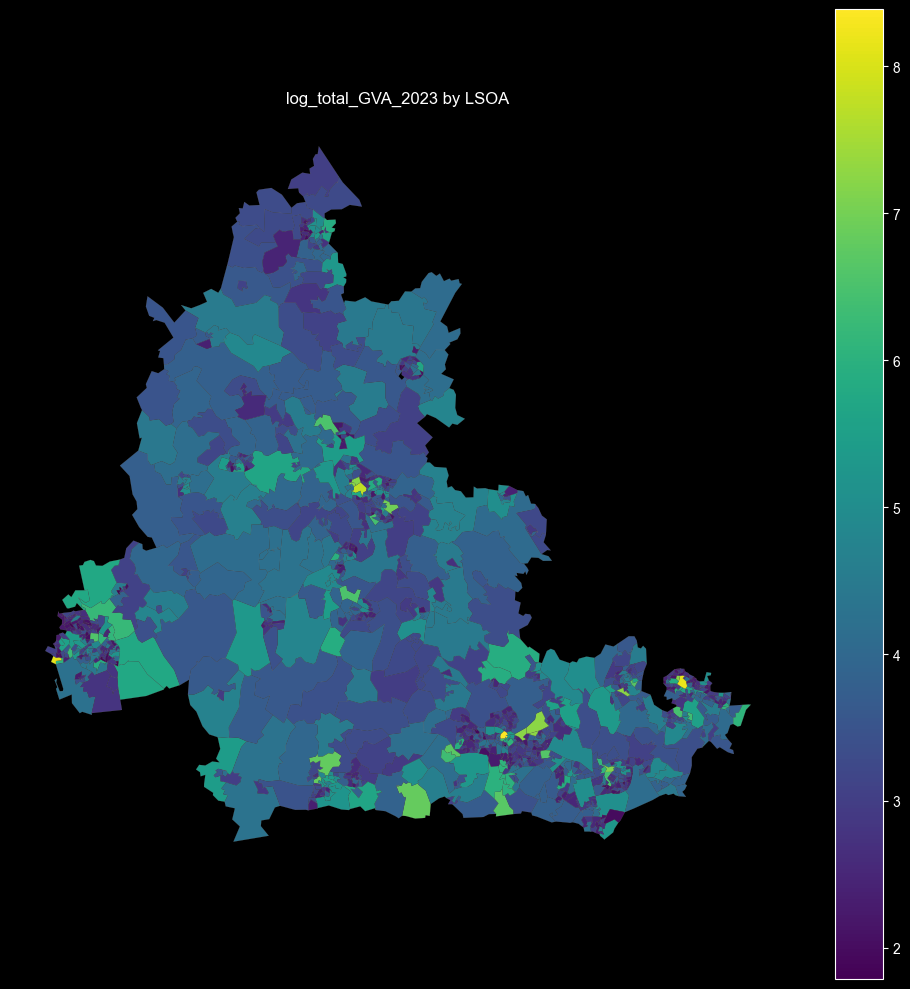

In [34]:
import geopandas as gpd

full = pd.concat([train, test], ignore_index=True)
gdf = (
    gpd.read_file("LSOA_boundaries.geojson")
    .merge(full, on="LSOA21CD")
)

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(column=target_total,
         cmap="viridis",
         legend=True,
         ax=ax,
         linewidth=0.1,
         edgecolor="grey",
         missing_kwds={"color": "lightgrey", "label": "No data"})

ax.set_title(f"{target_total} by LSOA")
ax.axis("off")
plt.tight_layout()
plt.show()

In [38]:
from libpysal.weights import KNN
from esda.moran import Moran
g = gdf.dropna(subset=[target]).reset_index(drop=True)
w = KNN.from_dataframe(g, k=6); w.transform = "r"
mi = Moran(g[target], w)
print("Moran's I (KNN):", round(mi.I, 3), "p:", round(mi.p_sim, 3))

Moran's I (KNN): 0.082 p: 0.001


## B10. Distributions of the selected DAG features

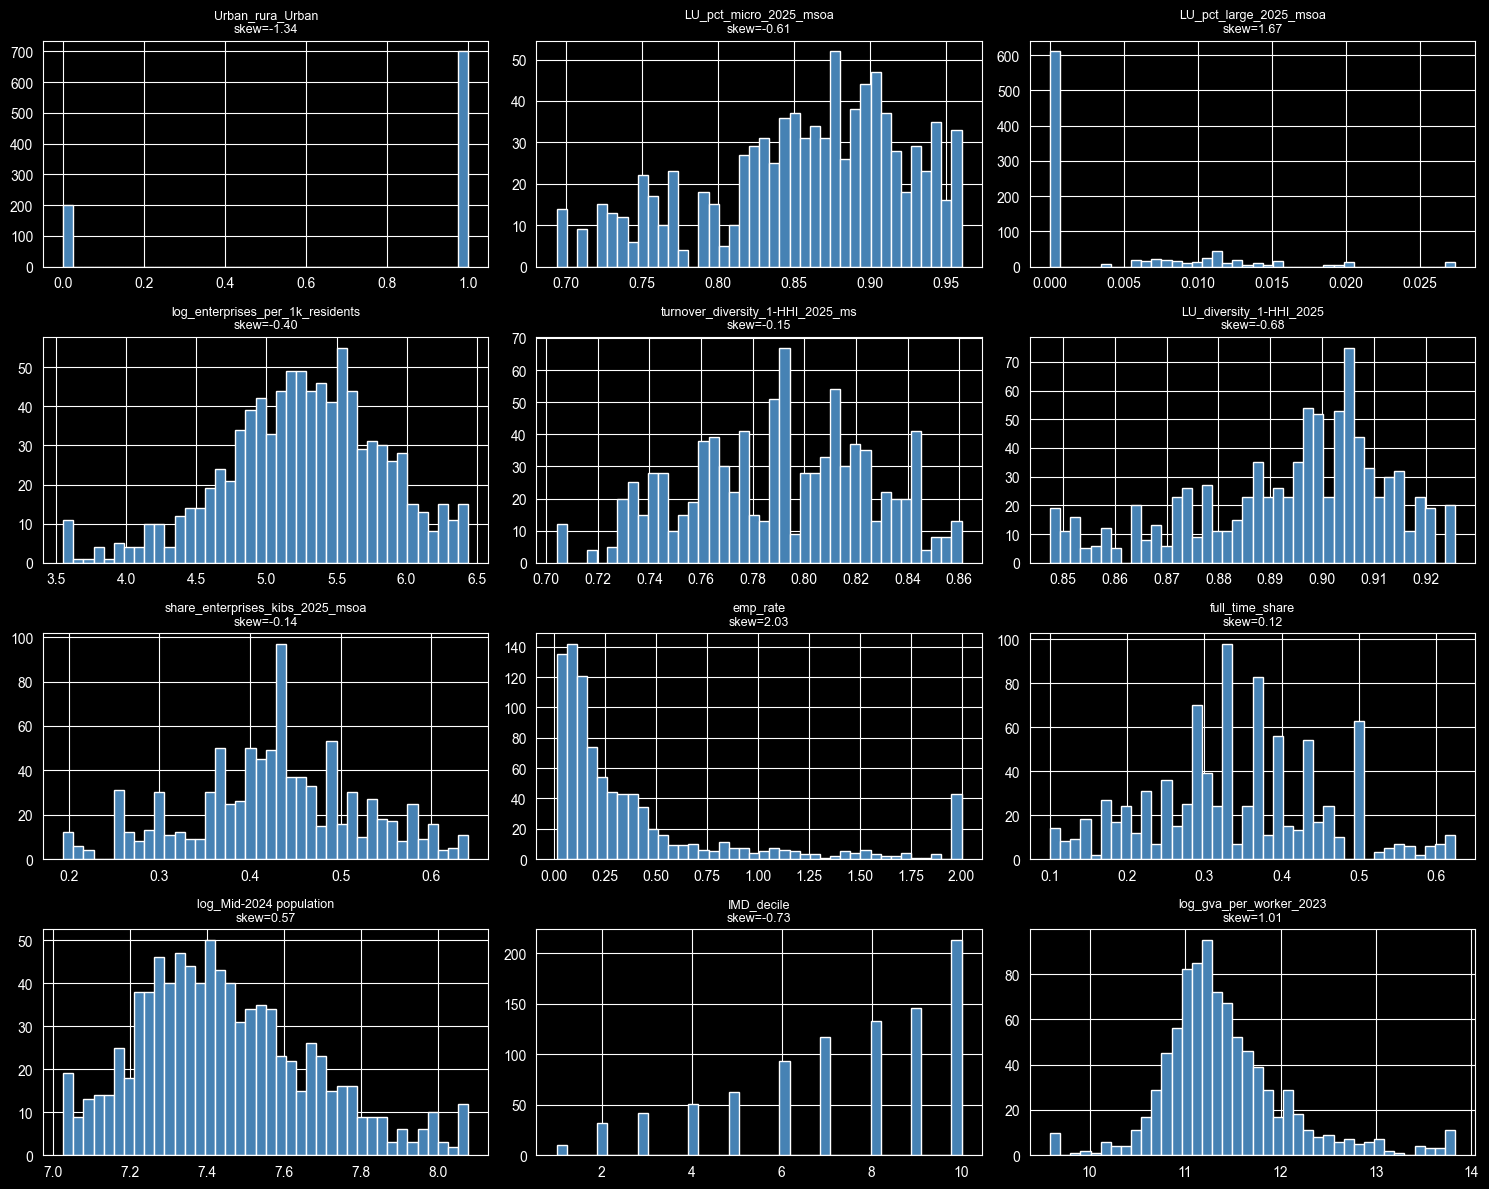

In [36]:
key = dag_num + [target]
ncol = 3; nrow = (len(key) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3 * nrow))
for ax, c in zip(axes.flat, key):
    dfw[c].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{short(c)}\nskew={dfw[c].skew():.2f}", fontsize=9)
for ax in axes.flat[len(key):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Part C — Export selected features

In [37]:
train[cols].to_csv("train.csv", index=False)
test[cols].to_csv("test.csv", index=False)
print(train[cols].shape, test[cols].shape)
train[cols].head()

(900, 18) (221, 18)


,LSOA21CD,LSOA21NM,MSOA21CD,MSOA21NM,log_total_GVA_2023,log_gva_per_worker_2023,is_swindon,Urban_rura_Urban,LU_pct_micro_2025_msoa,LU_pct_large_2025_msoa,log_enterprises_per_1k_residents_2025,turnover_diversity_1-HHI_2025_msoa,LU_diversity_1-HHI_2025,share_enterprises_kibs_2025_msoa,emp_rate,full_time_share,log_Mid-2024 population,IMD_decile
0,E01015471,Swindon 028A,E02006849,Swindon 028,2.776581,12.145797,Swindon,1.0,0.844828,0.000000,4.667658,0.770833,0.896111,0.458333,0.035149,0.375000,7.730614,10
1,E01015473,Swindon 008A,E02003219,Swindon 008,6.207100,10.785581,Swindon,0.0,0.820225,0.011236,5.864770,0.816569,0.921664,0.405229,2.000000,0.219512,7.686162,7
2,E01015475,Swindon 015A,E02003226,Swindon 015,4.612086,10.950263,Swindon,1.0,0.823529,0.011765,4.830697,0.830385,0.905896,0.290323,0.701684,0.142857,7.822044,4
3,E01015477,Swindon 015C,E02003226,Swindon 015,3.035241,11.280047,Swindon,1.0,0.823529,0.011765,5.149617,0.830385,0.905896,0.290323,0.138198,0.500000,7.501082,4
4,E01015478,Swindon 021A,E02003232,Swindon 021,5.274071,12.975200,Swindon,1.0,0.895522,0.000000,5.205738,0.765755,0.904844,0.406780,0.276583,0.333333,7.395108,7
